This notebook implements a two-layer neural network for the Iris dataset. The network architecture includes a ReLU activation layer with 10 units, followed by a softmax output layer. The structure and training process are defined in the `train()` function.

Stochastic gradient descent (SGD) is used for learning the parameters. The `compute_neural_net_loss()` function handles both forward and backward propagation. 

In [1]:
import numpy as np
import os, sys
import math
import matplotlib.pyplot as plt

In [2]:
# Data sets
IRIS_TRAINING = "/kaggle/input/iris-ds/iris_training.csv"
IRIS_TEST = "/kaggle/input/iris-ds/iris_test.csv"

def get_data():
    # Load datasets.
    train_data = np.genfromtxt(IRIS_TRAINING, skip_header=1, 
        dtype=float, delimiter=',') 
    test_data = np.genfromtxt(IRIS_TEST, skip_header=1, 
        dtype=float, delimiter=',') 
    train_x = train_data[:, :4]
    train_y = train_data[:, 4].astype(np.int64)
    test_x = test_data[:, :4]
    test_y = test_data[:, 4].astype(np.int64)

    return train_x, train_y, test_x, test_y

To complete the neural network implementation, I need to follow these steps:

First, I'll implement the forward pass to compute the network's output. This involves calculating the loss, which includes both the data loss using the softmax classifier and the L2 regularization loss for the weight matrices W1 and W2. I'll store the computed loss in the loss variable, ensuring that the regularization term is multiplied by 0.5 for consistency.

Next, I'll implement the backward pass to compute the gradients of the loss with respect to the network's weights and biases. These gradients will be stored in the grads dictionary, with the keys 'W1', 'b1', 'W2', and 'b2' corresponding to the respective gradients. I'll also account for the contribution of the regularization term in these gradients.

To facilitate these processes, I'll create helper functions: `affine_relu_forward()`, `affine_forward()`, `softmax_loss()`, `affine_backward()`, and `affine_relu_backward()`. These functions will assist in completing both the forward and backward passes efficiently.

In [3]:
def compute_neural_net_loss(params, X, y, reg=0.0):

    # Unpack variables from the params dictionary
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    N, D = X.shape

    #  Initializes variables as an empty dictionary 
    loss = 0.0
    grads = {}

    scores = None
    
    # Define function affine_relu_forward() and call it
    def affine_relu_forward(x, w, b):

      # Apply ReLU activation function on the scores
      out = np.maximum(np.dot(x, w) + b, 0)
      cache = (x, w, b, out)
      return out, cache
    
    out_1, cache_1 = affine_relu_forward(X, W1, b1) 
    
    
    # Define function affine_forward(), where compute scores and call it. Note: The softmax probabilities (scores) and the softmax loss are calculated in softmax_loss()
    def affine_forward(x, w, b):

      # Calculate the scores by performing the affine transformation
      out = np.dot(x, w) + b
      cache = (x, w, b, out)
      return out, cache

    out_2, cache_2 = affine_forward(out_1, W2, b2)

    scores = out_2

    # If y is None then we are in test mode so just return scores
    if y is None:
      return scores

    # Define function softmax_loss(), where calculate the softmax probabilities, data loss and call the function
    def softmax_loss(x, y):

      scores = x
      num_examples = x.shape[0]
      # Ensure numerical stability by subtracting the maximum score
      stab = np.amax(scores, axis=1)
      scores -= stab.reshape(num_examples, 1)
      # Calculate the exponentials of the adjusted scores
      exp_scores = np.exp(scores)
      # Calculate the softmax probabilities
      dx = exp_scores / np.sum(exp_scores, axis=1)[:, None]
      # Compute the cross-entropy loss and normalize by the number of examples
      loss = -np.sum(np.log(dx[range(0, num_examples), y])) / num_examples
      # Compute the gradient of the softmax loss
      dx[range(num_examples), y] = dx[range(num_examples), y] - 1
      dx = dx/num_examples
      return loss, dx
    
    loss, dscores = softmax_loss(scores, y)

    # Update the loss with regularization loss
    loss += 0.5*reg*np.sum(W1**2) + 0.5*reg*np.sum(W2**2)

    # Define the function affine_backward() and call it
    def affine_backward(dout, cache):

      # Calculate the gradient of the loss with respect to the biases
      db = np.sum(dout, axis=0)
      # Calculate the gradient of the loss with respect to the weights
      dw = np.dot(cache[0].T, dout)
      # Calculate the gradient of the loss with respect to the input
      dx = np.dot(dout, cache[1].T)
      return dx, dw, db
    
    dx_2, dW2, db2 = affine_backward(dscores, cache_2)
    
    # Define the function affine_relu_backward() and call it
    def affine_relu_backward(dout, cache):

      dx = dout
      # Zero out the gradients where the ReLU activation was not activated during the forward pass
      dx[cache[3] <= 0] = 0
      # Calculate the gradient of the loss with respect to the biases
      db = np.sum(dx, axis=0)
      # Calculate the gradient of the loss with respect to the weights
      dw = np.dot(cache[0].T, dx)
      return dx, dw, db
    
    dx_1, dW1, db1 = affine_relu_backward(dx_2, cache_1)

    # Store gradients in grads
    grads['W1']=dW1
    grads['W2']=dW2
    grads['b1']=db1
    grads['b2']=db2
    
    # Add regulariazion gradient contribution
    grads['W2'] += reg*params['W2']
    grads['W1'] += reg*params['W1']
    
    return loss, grads

For the next steps, I need to define the `train()` function. This function will initialize the network parameters, calculate accuracy using the `acc()` function, and update the parameters using the stochastic gradient descent function `sgd_update()`. Additionally, the function will print out the loss and accuracies during training.

To calculate the accuracy, I'll define the `acc()` function, which compares the true labels with the predicted labels and returns the proportion of correct predictions. The `sgd_update()` function will be used to update the network parameters by applying the gradients computed during backpropagation, using the specified learning rate.

For prediction, I'll implement the `predict()` function, which uses the trained parameters to output the predicted labels for a given set of input data. This involves performing a forward pass through the network and selecting the class with the highest score.

Finally, in the `train()` function, I'll use mini-batch stochastic gradient descent to optimize the network parameters. I'll set up the network with an initial random initialization of parameters, and then iteratively update these parameters based on the computed gradients. Throughout the training process, I'll keep track of and print the loss and accuracy metrics for both the training and test sets, updating them every 10 epochs for monitoring the training progress.

In [4]:
# Define function for accuracy
def acc(ylabel, y_pred):

  # Compare true labels with predicted labels and calculate the mean
  accuracy = np.mean(ylabel == y_pred)
  return accuracy

# Define function for performing a stochastic gradient descent (SGD) update of the model parameters
def sgd_update(params, grads, learning_rate):

    # Iterate over each parameter in the dictionary
    for param_name in params:
       # Update the parameter using the SGD update rule
       params[param_name] += -learning_rate * grads[param_name]

# Define function for prediction
def predict(params, X):

    # Extract weights and biases from the parameters dictionary
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    # Initialize an array to store predicted labels
    y_pred = np.zeros(X.shape[1])

    # Define ReLU activation function
    relu_func = lambda x: x * (x > 0)
    
    # Forward pass through the network
    hidden_layer1_output = np.dot(X, W1)+b1
    activation_output  = relu_func(hidden_layer1_output)
    hidden_layer2_output  = np.dot(activation_output, W2)+b2
    
    # Predict the class with the highest score for each data point
    y_pred = np.argmax(hidden_layer2_output , axis=1)
    
    return y_pred

def train(X, y, Xtest, ytest, learning_rate=1e-3, reg=1e-5, max_epochs=100, batch_size=20):
    
    num_train, dim = X.shape
    num_classes = np.max(y) + 1  # assume y takes values 0...K-1 where K is the number of classes
    num_iters_per_epoch = int(math.floor(1.0 * num_train / batch_size))

    # Randomly initialize parameters
    params = {}
    std = 0.001
    params['W1'] = std * np.random.randn(dim, 10)
    params['b1'] = np.zeros(10)
    params['W2'] = std * np.random.randn(10, num_classes)
    params['b2'] = np.zeros(num_classes)

    
    # Lists to store loss and accuracy for plotting
    losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(max_epochs):
        # Shuffle the indices
        perm_idx = np.random.permutation(num_train)

        # Perform mini-batch SGD update:
        for it in range(num_iters_per_epoch):
            # Select a set of indices to create mini-batch
            idx = perm_idx[it * batch_size:(it + 1) * batch_size]
            batch_x = X[idx]
            batch_y = y[idx]

            # Compute loss and gradient 
            loss, grads = compute_neural_net_loss(params, batch_x, batch_y, reg)
            
            # Update the parameters
            sgd_update(params, grads, learning_rate)

        # Evaluate and print every 10 steps
        if epoch % 10 == 0:
            train_acc = acc(y, predict(params, X))
            test_acc = acc(ytest, predict(params, Xtest))
            print('Epoch %4d: loss = %.2f, train_acc = %.4f, test_acc = %.4f'
                  % (epoch, loss, train_acc, test_acc))
            
            # Append values for plotting
            losses.append(loss)
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)

    # Plotting
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(0, max_epochs, 10), losses, label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracies
    plt.subplot(1, 2, 2)
    plt.plot(range(0, max_epochs, 10), train_accuracies, label='Training Accuracy')
    plt.plot(range(0, max_epochs, 10), test_accuracies, label='Test Accuracy')
    plt.title('Training and Test Accuracies')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()        

    return params


To start the training process, I first need to set several hyperparameters, including the number of epochs (`max_epochs`), batch size (`batch_size`), learning rate (`learning_rate`), and regularization strength (`reg`). After defining these hyperparameters, I'll proceed to train the model using the `train()` function, which will optimize the network parameters based on the training data.

Once the model is trained, I will use the `predict()` function to classify two new samples. This involves passing these new samples through the trained network to predict their labels. The function will output the predicted classes for these samples.

To achieve this, I'll first call the `get_data()` function to obtain the training and testing datasets. Then, I'll invoke the `train()` function with the training and testing data, along with the defined hyperparameters, to train the model and retrieve the optimized parameters. Finally, using the `predict()` function and the trained parameters, I'll predict the classes of the new flower samples provided by the `new_samples()` function and print the predictions.

Epoch    0: loss = 1.10, train_acc = 0.3500, test_acc = 0.2667
Epoch   10: loss = 1.10, train_acc = 0.3500, test_acc = 0.2667
Epoch   20: loss = 1.09, train_acc = 0.3500, test_acc = 0.2667
Epoch   30: loss = 1.10, train_acc = 0.3500, test_acc = 0.2667
Epoch   40: loss = 1.10, train_acc = 0.3500, test_acc = 0.2667
Epoch   50: loss = 1.10, train_acc = 0.3500, test_acc = 0.2667
Epoch   60: loss = 1.08, train_acc = 0.3500, test_acc = 0.2667
Epoch   70: loss = 1.05, train_acc = 0.3500, test_acc = 0.2667
Epoch   80: loss = 1.04, train_acc = 0.3500, test_acc = 0.2667
Epoch   90: loss = 0.96, train_acc = 0.7000, test_acc = 0.5333
Epoch  100: loss = 0.90, train_acc = 0.7000, test_acc = 0.5333
Epoch  110: loss = 0.69, train_acc = 0.7000, test_acc = 0.5333
Epoch  120: loss = 0.60, train_acc = 0.7000, test_acc = 0.5333
Epoch  130: loss = 0.34, train_acc = 0.7167, test_acc = 0.5667
Epoch  140: loss = 0.36, train_acc = 0.7333, test_acc = 0.5667
Epoch  150: loss = 0.35, train_acc = 0.8500, test_acc =

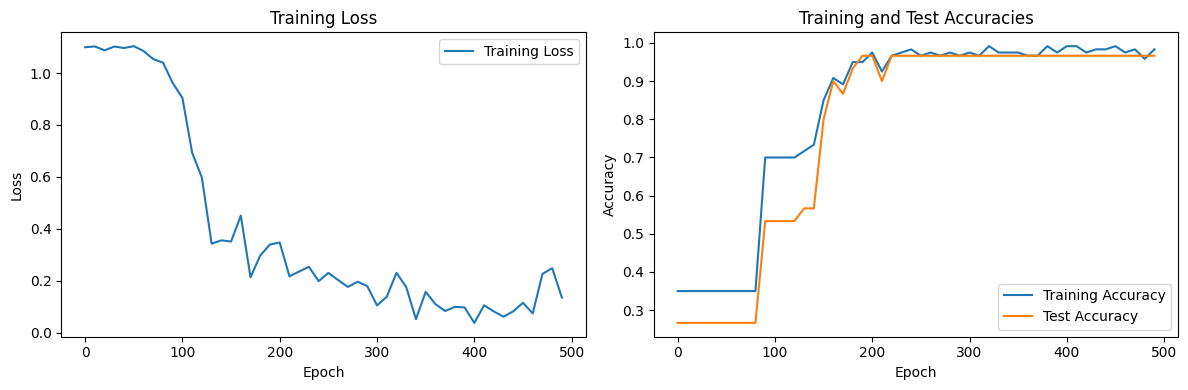

New Samples, Class Predictions:    [1 2]



In [5]:
# Set hyperparameters for training
max_epochs = 500
batch_size = 16
learning_rate = 0.01
reg = 0.0001

# Get training and testing data
train_x, train_y, test_x, test_y = get_data()
params = train(train_x, train_y, test_x, test_y, learning_rate, reg, max_epochs, batch_size)


# Classify two new flower samples.
def new_samples():
    return np.array(
      [[6.4, 3.2, 4.5, 1.5],
       [5.8, 3.1, 5.0, 1.7]], dtype=np.float32)
new_x = new_samples()

# Use the trained model to predict the classes of the new flower samples
predictions = predict(params, new_x)

# Print the predicted classes for the new flower samples
print("New Samples, Class Predictions:    {}\n".format(predictions))
